# Практическая работа № 4. Регрессионная модель

**Выполнил:** Эркинбеков Айман 
**Вариант:** B

## Цель работы

Построить модель линейной регрессии для предсказания выбросов CO₂ автомобилями, сравнить полный и сокращённый наборы признаков и оценить качество моделей.

## Данные

Используется датасет CO2 Emission by Vehicles с платформы Kaggle.

Целевая переменная: `CO2 Emissions(g/km)`.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Загрузка и общий осмотр данных

Файл загружается по относительному пути. Это позволяет запустить notebook на другом компьютере при сохранении структуры проекта.

In [2]:
DATA_PATH = "../data/co2_emissions_canada.csv"

df_raw = pd.read_csv(DATA_PATH)

print(f"Количество строк: {df_raw.shape[0]}")
print(f"Количество столбцов: {df_raw.shape[1]}")

display(df_raw.head())

Количество строк: 7385
Количество столбцов: 12


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
print("Названия столбцов:")
for column in df_raw.columns:
    print(column)

print("\nИнформация о таблице:")
df_raw.info()

print("\nКоличество пропусков:")
display(df_raw.isna().sum().to_frame(name="Пропуски"))

print(f"Количество полных дубликатов: {df_raw.duplicated().sum()}")

Названия столбцов:
Make
Model
Vehicle Class
Engine Size(L)
Cylinders
Transmission
Fuel Type
Fuel Consumption City (L/100 km)
Fuel Consumption Hwy (L/100 km)
Fuel Consumption Comb (L/100 km)
Fuel Consumption Comb (mpg)
CO2 Emissions(g/km)

Информация о таблице:
<class 'pandas.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   str    
 1   Model                             7385 non-null   str    
 2   Vehicle Class                     7385 non-null   str    
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   str    
 6   Fuel Type                         7385 non-null   str    
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Con

,Пропуски
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


Количество полных дубликатов: 1103


### Удаление полных дубликатов

Полные дубликаты удаляются до разбиения данных, чтобы одинаковые записи не попали одновременно в обучающую и тестовую выборки. Это не использует статистики целевой переменной и не создаёт утечку данных.

In [4]:
df = df_raw.drop_duplicates().reset_index(drop=True)

print(f"Размер до удаления дубликатов: {df_raw.shape}")
print(f"Размер после удаления дубликатов: {df.shape}")
print(f"Оставшиеся дубликаты: {df.duplicated().sum()}")

Размер до удаления дубликатов: (7385, 12)
Размер после удаления дубликатов: (6282, 12)
Оставшиеся дубликаты: 0


## 2. Классификация признаков

### Числовые признаки

- `Engine Size(L)` - объём двигателя;
- `Cylinders` - количество цилиндров;
- `Fuel Consumption City (L/100 km)` - городской расход;
- `Fuel Consumption Hwy (L/100 km)` - расход на трассе;
- `Fuel Consumption Comb (L/100 km)` - смешанный расход;
- `Fuel Consumption Comb (mpg)` - смешанный расход в милях на галлон.

### Категориальные признаки

- `Make` - производитель;
- `Model` - модель;
- `Vehicle Class` - класс автомобиля;
- `Transmission` - коробка передач;
- `Fuel Type` - тип топлива.

### Целевая переменная

`CO2 Emissions(g/km)` - выбросы углекислого газа в граммах на километр.

Столбцы `Make` и `Model` не используются в линейной модели, так как содержат большое количество категорий. В модель включены класс автомобиля, коробка передач и тип топлива.

## 3. Разбиение на обучающую и тестовую выборки

Разбиение выполняется до расчёта корреляций, заполнения пропусков, масштабирования и кодирования категорий. Пайплайн будет обучаться только на обучающей выборке.

In [5]:
target = "CO2 Emissions(g/km)"

numeric_features_all = [
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (L/100 km)",
    "Fuel Consumption Comb (mpg)"
]

categorical_features = [
    "Vehicle Class",
    "Transmission",
    "Fuel Type"
]

model_features = numeric_features_all + categorical_features

X = df[model_features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Размер X_train: {X_train.shape}")
print(f"Размер X_test: {X_test.shape}")
print(f"Размер y_train: {y_train.shape}")
print(f"Размер y_test: {y_test.shape}")

Размер X_train: (5025, 9)
Размер X_test: (1257, 9)
Размер y_train: (5025,)
Размер y_test: (1257,)


## 4. Проверка мультиколлинеарности

Корреляционная матрица рассчитывается только по обучающей выборке. Высокая корреляция между двумя признаками означает, что они содержат похожую информацию. Корреляция сама по себе не доказывает причинно-следственную связь.

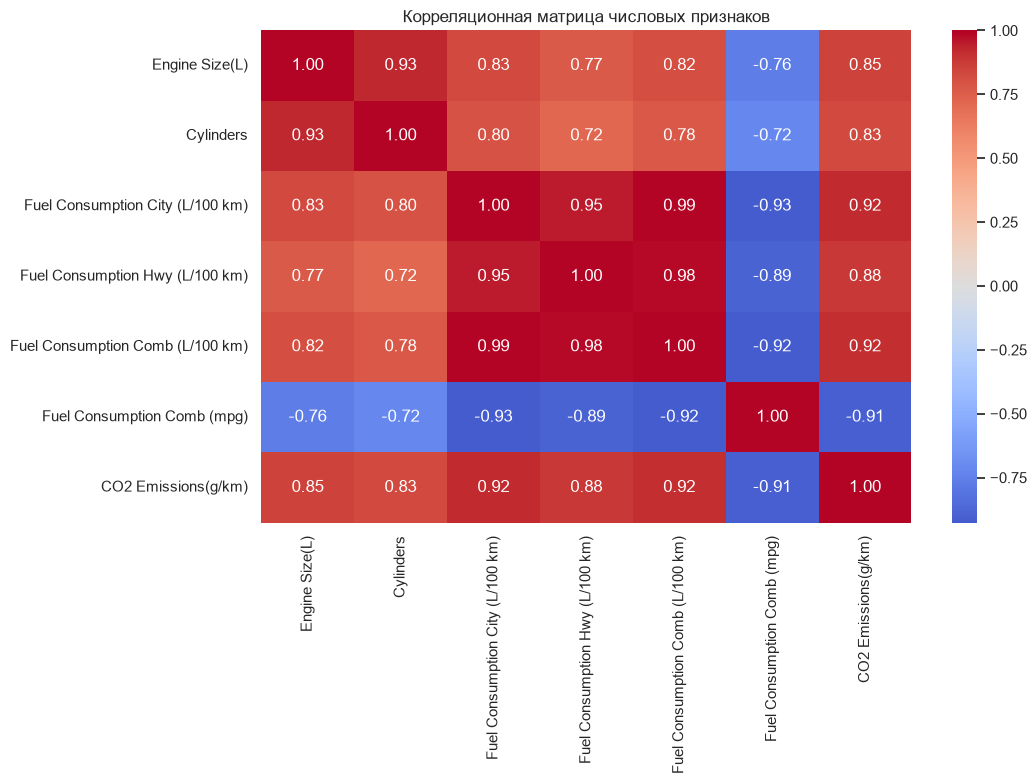

In [6]:
train_numeric = X_train[numeric_features_all].copy()
train_numeric[target] = y_train

correlation_matrix = train_numeric.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Корреляционная матрица числовых признаков")
plt.tight_layout()
plt.show()

### Вывод по корреляционной матрице

Городской, трассовый и смешанный расходы топлива сильно коррелируют между собой. Смешанный расход уже содержит информацию о расходе в городе и на трассе. Показатель в MPG выражает похожую информацию в другой единице измерения.

Объём двигателя и количество цилиндров также сильно связаны. Для сокращённой модели оставлены объём двигателя и смешанный расход в литрах на 100 км.

## 5. Пайплайн предобработки

Для числовых признаков используется заполнение медианой и масштабирование. Для категориальных признаков используется заполнение наиболее частым значением и one-hot кодирование.

Все преобразования входят в единый Pipeline. Пайплайн обучается только на `X_train`.

In [7]:
def create_regression_pipeline(numeric_features, categorical_features):
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=False
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features)
        ],
        remainder="drop"
    )

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LinearRegression())
        ]
    )

    return model_pipeline

In [8]:
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

## 6. Базовая модель

Базовая модель использует все доступные числовые признаки. Категориальные признаки обрабатываются тем же пайплайном и остаются одинаковыми в обеих моделях.

In [9]:
baseline_model = create_regression_pipeline(
    numeric_features_all,
    categorical_features
)

baseline_model.fit(X_train, y_train)

baseline_train_predictions = baseline_model.predict(X_train)
baseline_test_predictions = baseline_model.predict(X_test)

baseline_metrics = calculate_metrics(
    y_test,
    baseline_test_predictions
)

print(
    f"R2 на обучающей выборке: "
    f"{r2_score(y_train, baseline_train_predictions):.4f}"
)

print(
    f"R2 на тестовой выборке: "
    f"{baseline_metrics['R2']:.4f}"
)

display(
    pd.DataFrame(
        [baseline_metrics],
        index=["Базовая модель"]
    ).round(3)
)

R2 на обучающей выборке: 0.9931
R2 на тестовой выборке: 0.9894


/Users/aimanerkinbecovgmail.com/practical-work-1/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,MAE,MSE,RMSE,R2
Базовая модель,3.277,38.21,6.181,0.989


## 7. Сокращённая модель

Из модели удалены признаки, содержащие повторяющуюся информацию:

- `Cylinders`, так как количество цилиндров сильно связано с объёмом двигателя;
- городской и трассовый расход, так как они представлены смешанным расходом;
- расход в MPG, так как он выражает тот же расход топлива в другой единице.

В сокращённой модели остаются объём двигателя и смешанный расход топлива.

In [10]:
numeric_features_reduced = [
    "Engine Size(L)",
    "Fuel Consumption Comb (L/100 km)"
]

reduced_model = create_regression_pipeline(
    numeric_features_reduced,
    categorical_features
)

reduced_model.fit(X_train, y_train)

reduced_train_predictions = reduced_model.predict(X_train)
reduced_test_predictions = reduced_model.predict(X_test)

reduced_metrics = calculate_metrics(
    y_test,
    reduced_test_predictions
)

print(
    f"R2 на обучающей выборке: "
    f"{r2_score(y_train, reduced_train_predictions):.4f}"
)

print(
    f"R2 на тестовой выборке: "
    f"{reduced_metrics['R2']:.4f}"
)

display(
    pd.DataFrame(
        [reduced_metrics],
        index=["Сокращённая модель"]
    ).round(3)
)

R2 на обучающей выборке: 0.9922
R2 на тестовой выборке: 0.9880


/Users/aimanerkinbecovgmail.com/practical-work-1/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,MAE,MSE,RMSE,R2
Сокращённая модель,3.347,43.212,6.574,0.988


In [11]:
comparison = pd.DataFrame(
    {
        "Базовая модель": baseline_metrics,
        "Сокращённая модель": reduced_metrics
    }
).T

comparison["Изменение RMSE относительно базовой, %"] = (
    comparison["RMSE"] / comparison.loc["Базовая модель", "RMSE"] - 1
) * 100

display(comparison.round(3))

,MAE,MSE,RMSE,R2,"Изменение RMSE относительно базовой, %"
Базовая модель,3.277,38.210,6.181,0.989,0.000
Сокращённая модель,3.347,43.212,6.574,0.988,6.344


In [12]:
rmse_limit = baseline_metrics["RMSE"] * 1.10

if reduced_metrics["RMSE"] <= rmse_limit:
    final_model_name = "Сокращённая модель"
    final_model = reduced_model
    final_predictions = reduced_test_predictions
    final_metrics = reduced_metrics
else:
    final_model_name = "Базовая модель"
    final_model = baseline_model
    final_predictions = baseline_test_predictions
    final_metrics = baseline_metrics

print(f"Выбранная итоговая модель: {final_model_name}")
print(
    f"MAE: {final_metrics['MAE']:.2f} г/км. "
    "В среднем прогноз отличается от реального значения "
    "примерно на указанное количество граммов CO2 на километр."
)
print(
    f"RMSE: {final_metrics['RMSE']:.2f} г/км. "
    "Метрика сильнее учитывает большие ошибки."
)
print(
    f"R2: {final_metrics['R2']:.4f}. "
    "Это доля изменчивости выбросов, объяснённая моделью "
    "на тестовой выборке."
)

Выбранная итоговая модель: Сокращённая модель
MAE: 3.35 г/км. В среднем прогноз отличается от реального значения примерно на указанное количество граммов CO2 на километр.
RMSE: 6.57 г/км. Метрика сильнее учитывает большие ошибки.
R2: 0.9880. Это доля изменчивости выбросов, объяснённая моделью на тестовой выборке.


## 8. Анализ предсказаний и остатков

На первом графике сравниваются реальные и предсказанные значения. Чем ближе точки к диагональной линии, тем точнее модель.

На втором графике показаны остатки. Остаток равен разнице между реальным и предсказанным значением.

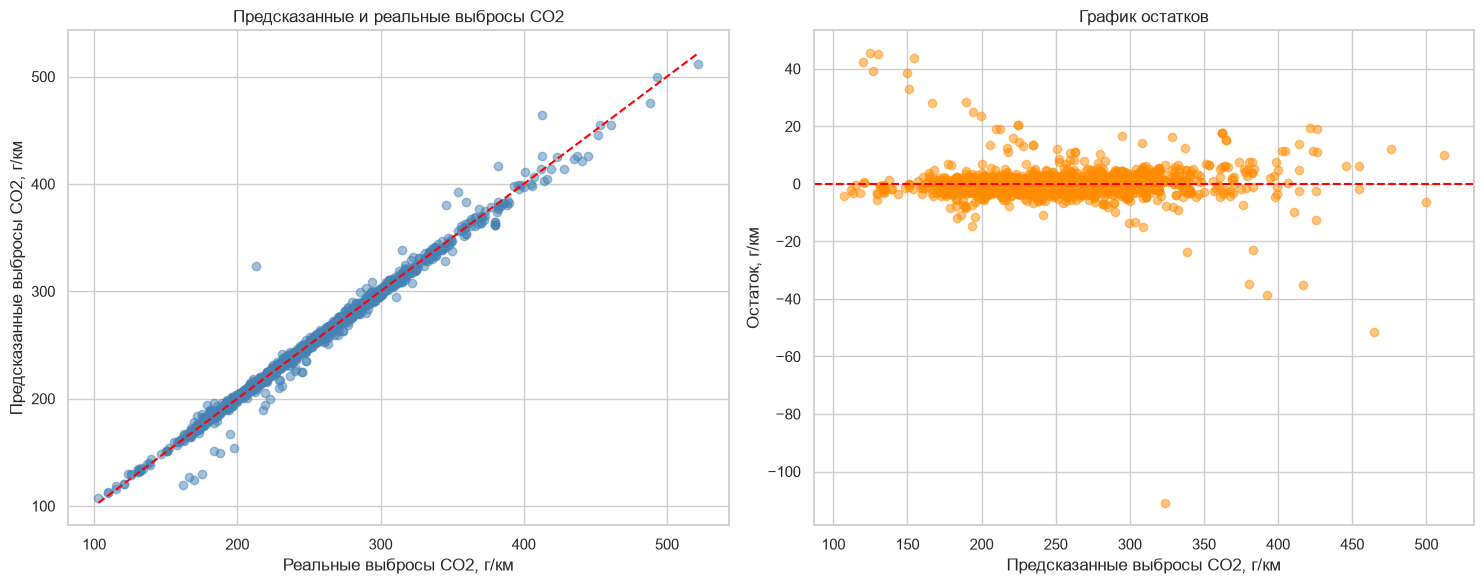

In [13]:
residuals = y_test - final_predictions

figure, axes = plt.subplots(1, 2, figsize=(15, 6))

minimum_value = min(y_test.min(), final_predictions.min())
maximum_value = max(y_test.max(), final_predictions.max())

axes[0].scatter(
    y_test,
    final_predictions,
    alpha=0.5,
    color="steelblue"
)

axes[0].plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="red",
    linestyle="--"
)

axes[0].set_title("Предсказанные и реальные выбросы CO2")
axes[0].set_xlabel("Реальные выбросы CO2, г/км")
axes[0].set_ylabel("Предсказанные выбросы CO2, г/км")

axes[1].scatter(
    final_predictions,
    residuals,
    alpha=0.5,
    color="darkorange"
)

axes[1].axhline(
    y=0,
    color="red",
    linestyle="--"
)

axes[1].set_title("График остатков")
axes[1].set_xlabel("Предсказанные выбросы CO2, г/км")
axes[1].set_ylabel("Остаток, г/км")

plt.tight_layout()
plt.show()

### Вывод по графикам

Большая часть точек на графике реальных и предсказанных значений расположена рядом с диагональной линией. Это означает, что модель в целом правильно оценивает выбросы CO₂.

Остатки в основном распределены вокруг нуля. При этом встречаются отдельные автомобили с более крупными ошибками. Явного постоянного смещения вверх или вниз не наблюдается. Линейная модель передаёт основную зависимость, но не объясняет все особенности отдельных автомобилей.

## Итоговый вывод

1. Целевой переменной являются выбросы CO₂ в граммах на километр. Перед моделированием были удалены полные дубликаты.

2. Данные были разделены на обучающую и тестовую выборки до расчёта статистик и обучения преобразований. Это предотвращает утечку информации из тестовой выборки.

3. Базовая модель использовала все числовые признаки. Для неё были рассчитаны MAE, MSE, RMSE и R² на тестовой выборке.

4. Корреляционная матрица показала сильную связь между городским, трассовым и смешанным расходом топлива. Также сильная связь обнаружена между объёмом двигателя и количеством цилиндров.

5. В сокращённой модели оставлены объём двигателя и смешанный расход топлива. Категориальные признаки обрабатывались через one-hot кодирование.

6. Итоговая модель имеет MAE около **3.35 г/км** и RMSE около **6.57 г/км**. Это означает, что средняя ошибка прогноза измеряется несколькими граммами CO₂ на километр, а RMSE сильнее учитывает редкие крупные ошибки.

7. Для итогового использования выбрана **Сокращённая модель**, поскольку она показывает подходящее качество на тестовых данных и не содержит лишних взаимосвязанных признаков.